# Risolvere il problema delle regine con la teoria dei grafi
<div style="text-align: right"> Tutor: Lorenzo Ciarpaglini
<div style="text-align: right"> Author: Fabio Ciccarelli

---
References:

*   https://networkx.org/documentation/stable/reference/index.html
*   https://www.tandfonline.com/doi/pdf/10.1080/00029890.1994.11997004

---


Con questo notebook impareremo come risolvere una variante del problema delle regine usando la teoria dei grafi.


## 0. Installiamo gurobipy e optimods

In [1]:
# !pip install gurobipy
# !pip install gurobi-optimods

## 1. Importiamo le librerie necessarie

In [1]:
import numpy as np
import networkx as nx

import gurobipy as gp
from gurobipy import GRB
from gurobi_optimods.mwis import maximum_weighted_independent_set

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

import time

## 2. Alcune utili funzioni

(Strumentopoli misteriosi che ci saranno utili più avanti!)

### 2.1 Disegniamo la scacchiera

Questa funzione ha uno scopo puramente didattico: non è necessario che la capiate fino in fondo, ma se siete curiosi di mettere alla prova le vostre skill informatiche potete dare un'occhiata! 😉

In [2]:
# Function to plot the game-board (check it if you like challenges!)
def plot_board(board, cmap, sol = []):
    
    n = len(cmap)
    
    # Create a blank grid of size n x n
    grid = np.zeros((n, n, 3))

    # Fill the grid with the corresponding colors using matplotlib's color module
    for (i, j), color in board.items():
        grid[i, j] = mcolors.to_rgb(cmap[color])


    for i in range(n):
        plt.plot([i-0.5, i-0.5], [-0.5, 8.5], c = 'black', linewidth = 0.6)
        plt.plot([-0.5, 8.5], [i-0.5, i-0.5], c = 'black', linewidth = 0.6)

    
    # Make the borders of the colored areas thicker
    for i in range(n):
        for j in range(n):
            if i != n-1:
                if board[(i,j)] != board[(i+1,j)]:
                    plt.plot([j-0.5, j+0.5], [i+0.5, i+0.5], c = 'black', linewidth = 2)
            if j != n-1:
                if board[(i,j)] != board[(i,j+1)]:
                    plt.plot([j+0.5, j+0.5], [i-0.5, i+0.5], c = 'black', linewidth = 2)
                    
    # Do we have a feasible solution? Let's plot it!                
    if sol:
        for i in range(n):
            for j in range(n):
                if (i,j) in sol:
                    # Let's plot the queens...
                    img = mpimg.imread('./crown.png')

                    imagebox = OffsetImage(img, zoom=0.042) 

                    ab = AnnotationBbox(imagebox, (j, i), frameon=False)

                    plt.gca().add_artist(ab)
                
                else:
                    # ...and the erased cells
                    plt.text(j, i, 'x', fontsize=10, ha='center', va='center')

                
                


    plt.xticks([])
    plt.yticks([])

    # Plot the grid
    plt.imshow(grid, interpolation='nearest')
    plt.show()
    
    
    return


### 2.2 Costruiamo il grafo associato al problema

<ins>Il problema delle regine può essere ricondotto a un problema su grafo</ins>. In particolare, vorremmo trovare un sottoinsieme delle caselle in cui posizionare le regine, tale che le regine posizionate non siano *in conflitto* tra loro. 

Vi ricorda qualcosa? 🤔 \
Sembra un problema di **massimo insieme stabile su grafo**! 😯

Possiamo modellare i **conflitti come archi** che collegano caselle che si trovano sulla stessa riga, sulla stessa colonna, che hanno lo stess colore o che appartengono allo stesso *intorno*.

La funzione ``plot_graph`` costruisce e mostra il grafo associato al problema delle regine.

In [3]:
def plot_graph(board, cmap):
    
    n = len(cmap)
    
    # Build the graph corresponding to the chessboard
    G = nx.Graph()

    G.add_nodes_from([
        ( node, { 'color': cmap[board[node]] } ) 
            for node in board
        ])


    for col in cmap:
        same_col_cells = []
        for cell in board:
            if board[cell] == col:
                same_col_cells.append(cell)
        
        # Same color cells are linked to each other, let us add an edge!
        for n1 in range(len(same_col_cells)-1):
            for n2 in range(n1+1, len(same_col_cells)):
                G.add_edge(same_col_cells[n1], same_col_cells[n2])

                
    
    # We also need to add an edge between each pair of cells belonging to the same "neighborhood"...
    for i in range(n-1):
        for j in range(n):
            if j == 0:
                G.add_edge((i,j), (i+1, j+1))
                continue
            elif j == n-1:
                G.add_edge((i,j), (i+1, j-1))
                continue
            else:
                G.add_edge((i,j), (i+1, j+1))
                G.add_edge((i,j), (i+1, j-1))


    # ...same row...
    for i in range(n):
        for n1 in range(n-1):
            for n2 in range(n1+1, n):
                G.add_edge((i, n1), (i, n2))


    # ...and same column!       
    for j in range(n):
        for n1 in range(n-1):
            for n2 in range(n1+1, n):
                G.add_edge((n1, j), (n2, j))


    # Plot the graph in a very nice way (with correct colors and nodes position)
    node_colors = [G.nodes[node]['color'] for node in G.nodes()]
    pos = {node : (node[1], n - node[0]) for node in G.nodes} 

    nx.draw(G, pos = pos, node_color=node_colors)
    
    return G

## 3. Risolvere il problema

### 3.1 Un primo approccio: modello MIP e solver commerciale

Ad alcuni sarà già venuto in mente di risolvere il problema scrivendone la **formulazione naturale** e lasciandolo risolvere da un solutore commerciale.

Di seguito, per i più curiosi, una possibile formulazione del problema che non richiede la costruzione di un grafo.

Introduciamo i seguenti insiemi:

$R = \{1, \dots, n\} \quad \text{Insieme delle righe della scacchiera}$ \
$C = \{1, \dots, m\} \quad \text{Insieme delle colonne della scacchiera}$ \
$\mathcal{A} = \{1, \dots, p\} \quad \text{Insieme dei colori della scacchiera}$ 

(Notate che il problema in generale viene presentato su scacchiere quadrate, con numero di righe, colonne e colori uguali. Tuttavia, nessuno ci vieta di porre $n \neq m \neq p$)

Assumiamo inoltre di conoscere, per ogni casella $(i,j) \in R \times C$, il suo intorno $I(i,j) \subset R \times C$ (non è difficile da ottenere).

Per comodità, introduciamo anche la seguente funzione:

$g : R \times C \to A \quad \text{Data una casella sulla scacchiera, ne restituisce il colore.}$

E l'insieme delle caselle aventi lo stesso colore:

$\mathcal{G}(a) = \{(i, j) \in R \times C \,: \, g(i,j) = a \}, \quad \text{ con } a \in \mathcal{A} $

Infine, le variabili decisionali del problema:

$$ 
x_{ij} =
\begin{cases} 
1 \quad \quad \text{se una regina è posizionata sulla casella } (i,j) \quad \forall \, i \in R, j \in C \\
0 \quad \quad \text{altrimenti}
\end{cases}
$$


Una possibile formulazione del problema è dunque la seguente (notate bene che la funzione obiettivo è arbitraria, visto che si tratta di un problema di ammissibilità e dunque non necessita di funzione obiettivo):


&nbsp;

$$
\begin{align}
&&   \min_{\boldsymbol{x} \, \in \, \{0, 1\}^{m n}} \quad  \sum_{i \in R} \sum_{j \in C} x_{ij} \\
&& \sum_{i \in R} \quad x_{ij}   \, & = 1,     &  \forall \, j \in C, \\
&& \sum_{j \in C} \quad x_{ij}  \,  & = 1,     &  \forall \, i \in R, \\
&& \sum_{(i,j) \in \mathcal{G}(a)} \; x_{ij}  \,  & = 1,     &  \forall \, a \in \mathcal{A}, \\
&& \sum_{(h,k) \in I(i,j)} x_{hk}   & \leq 1,     &  \forall \, (i,j) \in R \times C. \\
\end{align}
$$

&nbsp;


La funzione ``solve_PL01_queens`` è una possibile implementazione di quanto appena descritto.

In [9]:
# Take a look if yo are interested in MILP modeling and commercial solvers!
# (This is just one of the possible formulations for the queens problem)

def solve_PL01_queens(board, color_map):
    
    
    n = int(len(board)**0.5)
    
    
    model = gp.Model('queens_puzzle')


    # x_{i,j} = 1 if a queen is put inside cell i,j
    x = model.addVars(range(n), range(n), vtype = GRB.BINARY, name = "x")  


    # Objective function (in theory, we could also use a dummy o.f.)
    model.setObjective(sum(x[i,j] for i in range(n) for j in range(n)), GRB.MAXIMIZE)

    # What about the constraints?
    
    # We need a queen for each row...
    model.addConstrs(sum(x[i, j] for i in range(n)) == 1 for j in range(n))
    
    # ...and for each column
    model.addConstrs(sum(x[i, j] for j in range(n)) == 1 for i in range(n))



    for col in color_map:
        same_col_cells = []
        for cell in board:
            if board[cell] == col:
                same_col_cells.append(cell)
        
        # Exactly one queen for each colored area
        model.addConstr(sum(x[i,j] for (i,j) in same_col_cells) == 1)


    
    # Remember not to put more than a queen in each possible neighborhood!
    # A nice trick here, we are not considering the entire neighborhood. Why? :-)
    for i in range(n-1):
        for j in range(n):
            if j == 0:
                model.addConstr(x[i,j] + x[i+1, j+1] <= 1)
                continue
            elif j == n-1:
                model.addConstr(x[i,j] + x[i+1, j-1] <= 1)
                continue
            else:
                model.addConstr(x[i,j] + x[i+1, j+1] <= 1)
                model.addConstr(x[i,j] + x[i+1, j-1] <= 1)



    # Let's solve it, GUROBI BRUTE FORCE!
    model.optimize()
    
    
    # Build and return the solution
    solution = []


    for (i,j) in board:
        if x[i,j].X == 1:
            solution.append((i,j))
            
    return solution

### 3.2 L'algoritmo built-in di NewtorkX

Come sappiamo, il problema di trovare l'indipendente di cardinalità massima all'interno di un grafo è un **problema NP-hard**: non vi sono dunque algoritmi efficienti per risolverlo all'ottimo. 😥

Per questo motivo, NetworkX implementa un metodo approssimato (o *euristico*) per risolvere il problema, basato sulla ricerca che potete trovare al seguente link:

*   https://link.springer.com/article/10.1007/BF01994876

Poiché approssimato, non ci aspettiamo che l'algoritmo di NX restituisca la soluzione ottima il 100% delle volte (e, in effetti, non è così). 😞


In [5]:
def heu_solve_ind_set_queens(G):
    
    # We just use an heuristic algorithm provided my NetworkX
    
    return nx.approximation.maximum_independent_set(G)

### 3.3 Gurobi Optimods: il meglio dei due mondi

Dato un grafo $G(N, E)$, sappiamo che il problema di massimo insieme stabile su grafo può essere modellato come segue:

&nbsp;

$$
\begin{align}
&&   \max_{\boldsymbol{x} \, \in \, \{0, 1\}^{|N|}} \quad  \sum_{v \, \in \, N} x_{v} \\
&&  x_{u} + x_{v}   \, & \leq 1,     &  \forall \; (u,v) \in E. \\
\end{align}
$$

&nbsp;

Possiamo dunque sfruttare il grafo costruito precedentemente e affidare a Gurobi il compito di trovare il massimo insieme stabile su di esso (che equivale alle celle in cui posizionare le regine). **Gurobi Optimods** ci permette di fare ciò senza dover scrivere la formulazione da zero, ma sfruttando un metodo pre-costruito.

In [4]:
def optimods_solve_independent_set(G, n):
    

    G_mod = nx.Graph()

    # This method requires a re-mapping of the nodes: we assign the nodes a number in range [0, n^2 - 1]
    for node in G.nodes:
        G_mod.add_node(node[0]*n + node[1])

    
    # The same must be done for the edges
    for edge in G.edges:
        node_1 = edge[0][0]*n + edge[0][1]
        node_2 = edge[1][0]*n + edge[1][1]
        G_mod.add_edge(node_1, node_2)




    node_colors = [G.nodes[node]['color'] for node in G.nodes()]
    pos = {node[0]*n + node[1] : (node[1], n - node[0]) for node in G.nodes} 
    
    
    # Vertex weights (just set all of them to 1)
    weights = np.ones(len(G_mod.nodes))

    # Compute maximum weighted independent set
    mwis = maximum_weighted_independent_set(G_mod, weights)


    # Now, let's go back to the old mapping of the nodes for the solution
    solution = []
    
    for i in mwis.x:
        n_row = i // n 
        n_col = i % n
        
        solution.append((n_row, n_col))
    
    return solution
    
    

## 4. Qualche esempio

Nelle celle che seguono, vengono presentati un paio di esempi di istanze di queens game e le loro relative soluzioni!

Se volete, potete mettervi alla prova provando a risolvere a mano problemi simili su:


*   https://www.mindgames.com/game/Daily+Queens     

Buon divertimento! 💪

### Griglia 7x7

In [5]:
# Dictionary defining the grid's cell colors
board = {
    # Row 1
    (0, 0): 'green', (0, 1): 'green', (0, 2): 'green', (0, 3): 'tan', (0, 4): 'tan', (0, 5): 'tan', (0, 6): 'blue',
    # Row 2
    (1, 0): 'green', (1, 1): 'green', (1, 2): 'green', (1, 3): 'green', (1, 4): 'tan', (1, 5): 'blue', (1, 6): 'blue',
    # Row 3
    (2, 0): 'green', (2, 1): 'green', (2, 2): 'tan', (2, 3): 'green', (2, 4): 'tan', (2, 5): 'tan', (2, 6): 'tan',
    # Row 4
    (3, 0): 'yellow', (3, 1): 'green', (3, 2): 'tan', (3, 3): 'tan', (3, 4): 'tan', (3, 5): 'tan', (3, 6): 'red', 
    # Row 5
    (4, 0): 'yellow', (4, 1): 'yellow', (4, 2): 'lightblue', (4, 3): 'tan', (4, 4): 'tan', (4, 5): 'tan', (4, 6): 'red',
    # Row 6
    (5, 0): 'lightblue', (5, 1): 'lightblue', (5, 2): 'lightblue', (5, 3): 'tan', (5, 4): 'tan', (5, 5): 'purple', (5, 6): 'purple',
    # Row 7
    (6, 0): 'lightblue', (6, 1): 'lightblue', (6, 2): 'tan', (6, 3): 'tan', (6, 4): 'purple', (6, 5): 'purple', (6, 6): 'purple'
}

# Define a color mapping for matplotlib
color_map = {
    'lightblue': '#7cb5b9',
    'red': '#b57878',
    'blue': '#718bbe',
    'yellow': '#bfb879',
    'green': '#98bb81',
    'purple': '#7d78be',
    'tan': '#bb946b', 
}

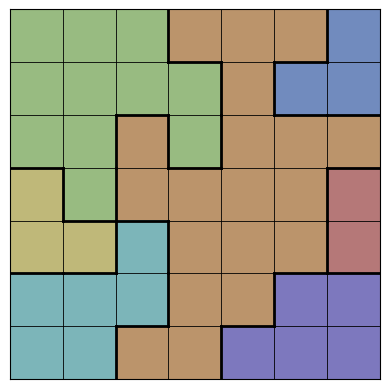

In [6]:
# WOW! It looks amazing!
plot_board(board, color_map)

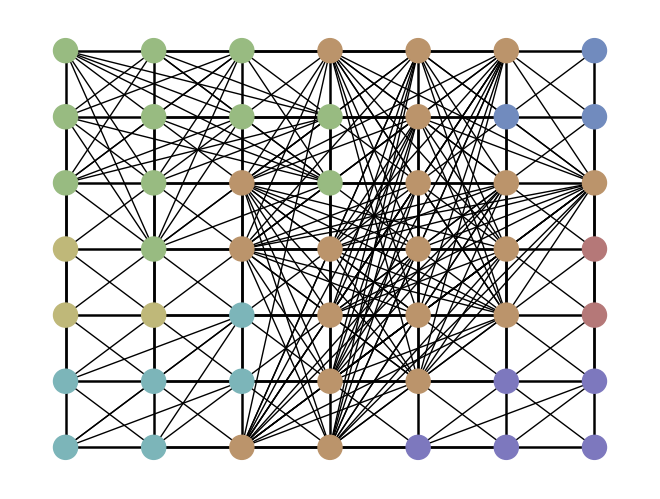

In [7]:
# Do you want to see this very nice graph?
G = plot_graph(board, color_map)

In [10]:
t1 = time.time()

# Initially, we solve it via a MIP commercial solver
sol1 = solve_PL01_queens(board, color_map)

t2 = time.time()

print("\n\n\n\n", "*"*100, "\n\nOptimal solution:", sol1, "\nTime:", t2-t1)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-30
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1280P, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 93 rows, 49 columns and 291 nonzeros
Model fingerprint: 0x4f9c5729
Variable types: 0 continuous, 49 integer (49 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 93 rows and 49 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 20 available processors)

Solution count 1: 7 

Optimal solution found (tolerance 1.00e-04)
Best objective 7.000000000000e+00, best bound 7.000000000000e+00, gap 0.00

In [11]:
t1 = time.time()

# Heuristic solution provided by NetworkX
sol2 = heu_solve_ind_set_queens(G)

t2 = time.time()

print("\n\n", "*"*100, "\n\nSub-optimal solution:", sol2, "\nTime:", t2-t1)



 **************************************************************************************************** 

Sub-optimal solution: {(6, 5), (0, 0), (4, 6), (1, 4), (5, 2)} 
Time: 0.021049022674560547


In [12]:
t1 = time.time()

# Optimal solution provided by mixing Gurobi with graph theory (Gurobi Optimods)
sol3 = optimods_solve_independent_set(G, 7)

t2 = time.time()

print("\n\n\n\n", "*"*100, "\n\nOptimal solution:", sol3, "\nTime:", t2-t1)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-30
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1280P, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 492 rows, 49 columns and 984 nonzeros
Model fingerprint: 0xe03ca743
Variable types: 0 continuous, 49 integer (49 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 5.0000000
Presolve removed 451 rows and 0 columns
Presolve time: 0.00s
Presolved: 41 rows, 49 columns, 287 nonzeros
Variable types: 0 continuous, 49 integer (49 binary)

Root relaxation: objective 7.000000e+00, 40 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     W

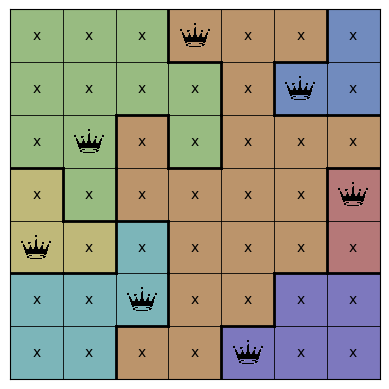

In [11]:
# Let's plot it! (Uncomment the one you want to show)

plot_board(board, color_map, sol1)
#plot_board(board, color_map, sol2)
# plot_board(board, color_map, sol3)

### Griglia 9x9

In [14]:
# Dictionary defining the grid's cell colors
board = {
    # Row 1
    (0, 0): 'tan', (0, 1): 'lightblue', (0, 2): 'lightblue', (0, 3): 'red', (0, 4): 'red', (0, 5): 'lightblue', (0, 6): 'lightblue', (0, 7): 'blue', (0, 8): 'blue',
    # Row 2
    (1, 0): 'tan', (1, 1): 'lightblue', (1, 2): 'lightblue', (1, 3): 'lightblue', (1, 4): 'red', (1, 5): 'lightblue', (1, 6): 'lightblue', (1, 7): 'blue', (1, 8): 'blue',
    # Row 3
    (2, 0): 'lightblue', (2, 1): 'lightblue', (2, 2): 'lightblue', (2, 3): 'lightblue', (2, 4): 'lightblue', (2, 5): 'lightblue', (2, 6): 'yellow', (2, 7): 'yellow', (2, 8): 'blue',
    # Row 4
    (3, 0): 'lightblue', (3, 1): 'lightblue', (3, 2): 'lightblue', (3, 3): 'yellow', (3, 4): 'yellow', (3, 5): 'yellow', (3, 6): 'yellow', (3, 7): 'yellow', (3, 8): 'yellow',
    # Row 5
    (4, 0): 'lightblue', (4, 1): 'purple', (4, 2): 'lightblue', (4, 3): 'yellow', (4, 4): 'yellow', (4, 5): 'yellow', (4, 6): 'yellow', (4, 7): 'yellow', (4, 8): 'yellow',
    # Row 6
    (5, 0): 'purple', (5, 1): 'purple', (5, 2): 'lightblue', (5, 3): 'lightblue', (5, 4): 'lightblue', (5, 5): 'yellow', (5, 6): 'yellow', (5, 7): 'yellow', (5, 8): 'yellow',
    # Row 7
    (6, 0): 'purple', (6, 1): 'purple', (6, 2): 'lightblue', (6, 3): 'green', (6, 4): 'green', (6, 5): 'yellow', (6, 6): 'pink', (6, 7): 'brown', (6, 8): 'brown',
    # Row 8
    (7, 0): 'purple', (7, 1): 'purple', (7, 2): 'lightblue', (7, 3): 'lightblue', (7, 4): 'green', (7, 5): 'green', (7, 6): 'pink', (7, 7): 'brown', (7, 8): 'brown',
    # Row 9
    (8, 0): 'purple', (8, 1): 'purple', (8, 2): 'lightblue', (8, 3): 'lightblue', (8, 4): 'lightblue', (8, 5): 'green', (8, 6): 'brown', (8, 7): 'brown', (8, 8): 'brown',
}

# Define a color mapping for matplotlib
color_map = {
    'lightblue': '#7cb5b9',
    'red': '#b57878',
    'blue': '#718bbe',
    'yellow': '#bfb879',
    'green': '#98bb81',
    'brown': '#ac8366',
    'purple': '#7d78be',
    'tan': '#bb946b', 
    'pink': '#b994bf'
}



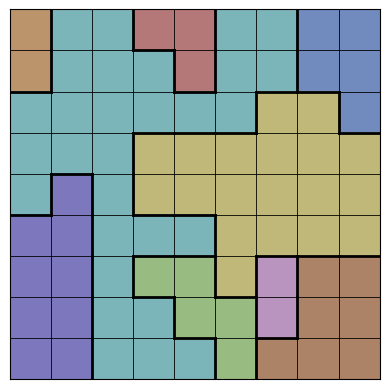

In [15]:
plot_board(board, color_map)

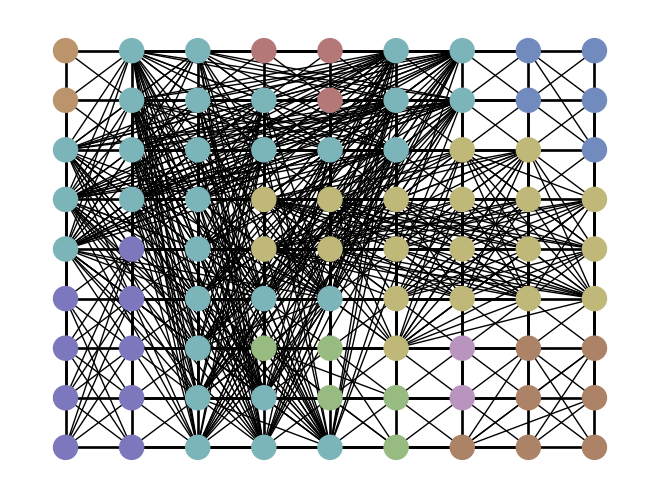

In [16]:
G = plot_graph(board, color_map)

In [ ]:
t1 = time.time()

# Initially, we solve it via a MIP commercial solver
sol1 = solve_PL01_queens(board, color_map)

t2 = time.time()

print("\n\n\n\n", "*"*100, "\n\nOptimal solution:", sol1, "\nTime:", t2-t1)

Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1280P, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 155 rows, 81 columns and 499 nonzeros
Model fingerprint: 0xa8f3fa74
Variable types: 0 continuous, 81 integer (81 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 155 rows and 81 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 20 available processors)

Solution count 1: 9 

Optimal solution found (tolerance 1.00e-04)
Best objective 9.000000000000e+00, best bound 9.000000000000e+00, gap 0.0000%




 ********************************************************************************

In [18]:
t1 = time.time()

# Heuristic solution provided by NetworkX
sol2 = heu_solve_ind_set_queens(G)

t2 = time.time()

print("\n\n", "*"*100, "\n\nSub-optimal solution:", sol2, "\nTime:", t2-t1)



 **************************************************************************************************** 

Sub-optimal solution: {(8, 8), (1, 2), (7, 1), (0, 0), (2, 6), (6, 3)} 
Time: 0.08094477653503418


In [19]:
t1 = time.time()

# Optimal solution provided by mixing Gurobi with graph theory (Gurobi Optimods)
sol3 = optimods_solve_independent_set(G, 9)

t2 = time.time()

print("\n\n\n\n", "*"*100, "\n\nOptimal solution:", sol3, "\nTime:", t2-t1)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-30
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1280P, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 1159 rows, 81 columns and 2318 nonzeros
Model fingerprint: 0xa886d858
Variable types: 0 continuous, 81 integer (81 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 6.0000000
Presolve removed 1087 rows and 6 columns
Presolve time: 0.00s
Presolved: 72 rows, 75 columns, 512 nonzeros
Variable types: 0 continuous, 75 integer (75 binary)

Root relaxation: objective 9.000000e+00, 60 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |   

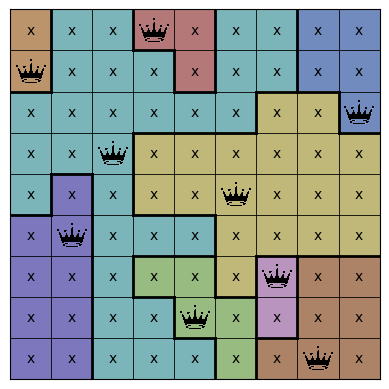

In [20]:
# Let's plot it! (Uncomment the one you want to show)

#plot_board(board, color_map, sol1)
#plot_board(board, color_map, sol2)
plot_board(board, color_map, sol3)